In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM
from Equipments.MCBOX import generate_test_voltages

from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [2]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [4]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


In [5]:
bias_channel = 11

In [6]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 2.8, bipolar = True, display = True)

Channel 11 has been set to 2.8 V.


In [ ]:
agilent = Agilent.Agilent('TCPIP0::169.254.110.10::inst0::INSTR',power_limit=0, freq_limit=40e9)

In [7]:
pm = ThorlabsPM.ThorlabsPM('USB0::0x1313::0x807B::241023118::0::INSTR')

Thorlabs,PM16-130,241023118,1.6.0



pm.readout(wavelength = 1064)

In [ ]:
pm.readout(wavelength=1064,average=50)

agilent.set_frequency(frequency = 0.7e9)

agilent.set_power(-1.8)

agilent.start_output()

agilent.stop_output()

agilent.set_power_limit(2)

agilent.set_power_limit(15)

## 700MHz

In [ ]:
agilent.set_frequency(frequency = 0.7e9)

output_power = []
RF_power_list = np.linspace(-30, 0, 31) # [dBm]
bias_list = np.linspace(-4,7,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power}dBm")
    agilent.set_power(RF_power)
    time.sleep(1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064,average=50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

In [ ]:
ps.Plot3D(x = RF_power_list+30, y = bias_list, Z = np.array(output_power),
          xlabel = "RF power after Amp (dBm) @ 700MHz", ylabel = "DC bias (V)", zlabel = "Output Power (W)",transpose=True)  

## 38GHz

In [ ]:
output_power = []
RF_power_list = np.linspace(-35,0,39) # [dBm]
bias_list = np.linspace(-9,9,41) # [V]
bias_channel = 11  # added this
print(RF_power_list)
print(bias_list)

agilent.set_frequency(frequency = 26.5e9)  # changed from 10 GHz
agilent.set_power(RF_power_list[0])
agilent.start_output()

for RF_power in RF_power_list:
    print(f"Now checking {RF_power}dBm")
    agilent.set_power(RF_power)
    time.sleep(0.1)
    sub_output_power = []
    for bias in bias_list:
        mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
        time.sleep(2e-3)
        power = pm.readout(wavelength = 1064,average=50) # changed from 780 nm
        sub_output_power.append(power)
    print(sub_output_power)
    output_power.append(sub_output_power)   
agilent.stop_output()
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

In [ ]:
ps.Plot3D(x = RF_power_list + 30, y = bias_list, Z = np.array(output_power)*1e+3,
          xlabel = "RF power (dBm) @ 26.5 GHz", ylabel = "DC bias (V)", zlabel = "Output Power (mW)", transpose = True)  

In [26]:
pm.close()

In [27]:
agilent.close()

NameError: name 'agilent' is not defined

In [28]:
mcbox.set_voltage_1chan(channel = bias_channel, voltage = 0, bipolar = True, display = True)

Channel 11 has been set to 0 V.


In [29]:
rm.list_opened_resources()

[]

In [30]:
rm.close()

## Check the polarization

In [8]:
def func(x,a,b,c,d):
    return a*np.sin(b*x+c)+d

In [23]:
bias_list = np.linspace(-9,9,41) # [V]
transmission = []

for bias in bias_list:
    mcbox.set_voltage_1chan(channel = bias_channel, voltage = bias, bipolar = True, display = False)
    power = pm.readout(wavelength = 1064,average=50)
    transmission.append(power)
    

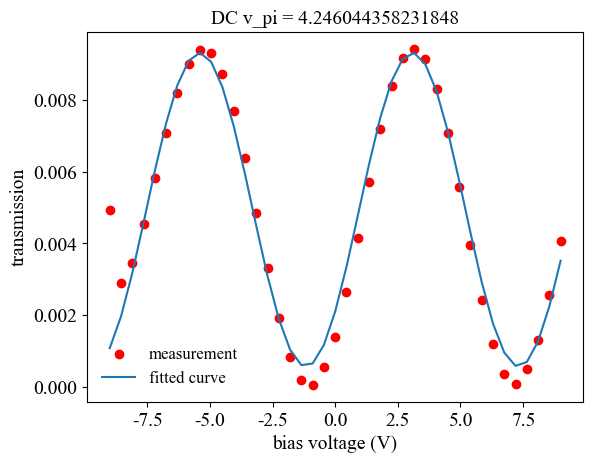

In [24]:
popt1, pcov1 = curve_fit(
            func, bias_list, transmission,maxfev=10000000,
        )

plt.figure()
plt.scatter(bias_list,np.array(transmission),c = "r",label = "measurement")
plt.plot(bias_list,func(bias_list,*popt1), label = "fitted curve")
plt.xlabel('bias voltage (V)')
plt.ylabel("transmission")
plt.title(f"DC v_pi = {np.pi/popt1[1]}")
plt.legend()
plt.show()

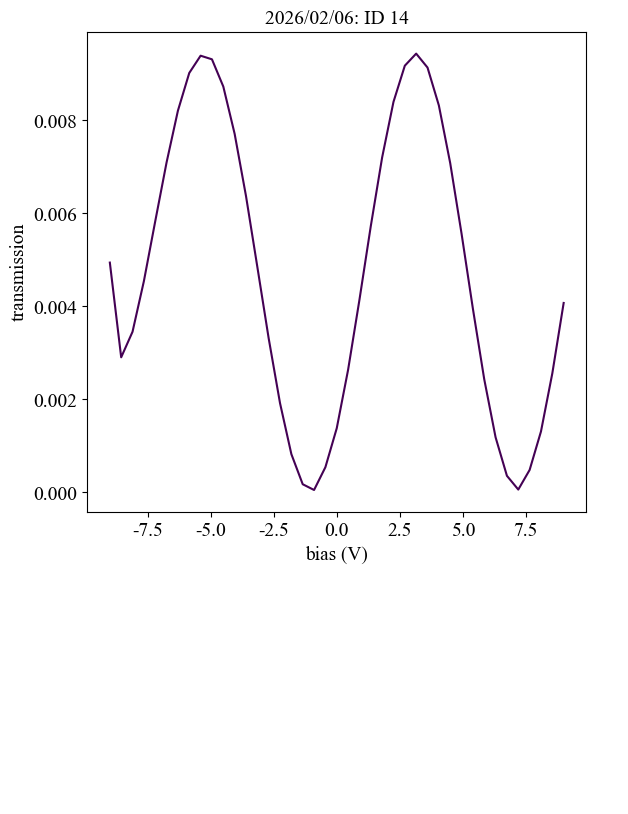

In [25]:
ps.Plot2D(x = bias_list, y = None, Z=transmission, xlabel='bias (V)', ylabel='Y', zlabel='transmission')


## test the degrade for RF

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
transimission_intensity = np.array([5.8,])
voltage = np.array([-4,-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0,])

In [ ]:
plt.scatter(voltage,transimission_intensity)

In [ ]:
def func(x,a,b,c):
    return a*np.sin(b*x)+c

popt1, pcov1 = curve_fit(
            func, voltage, transimission_intensity,maxfev=100000,
        )

In [ ]:
popt1

In [ ]:
plt.plot(voltage, func(voltage,*popt1))